# 03 · Comparación de modelos: 100 Hz vs 500 Hz

**Objetivo.** Decidir cuál de las dos redes entrenadas conviene más para clasificar ECG en las 5
superclases diagnósticas (`NORM, MI, STTC, CD, HYP`), poniendo en la balanza:

| Eje | Qué medimos |
|---|---|
| **Desempeño** | F1-macro / F1-micro en *test*, AUC-ROC y precisión/recall por clase |
| **Tamaño del modelo** | nº de parámetros entrenables y peso del `.pt` en disco |
| **Costo de cómputo** | FLOPs por inferencia y latencia real (ms/ECG) en GPU (MPS) y CPU |
| **Costo de datos** | tamaño de la entrada (12×1000 vs 12×5000) y peso del `.npy` en disco / RAM |

La pregunta de fondo: **¿vale la pena pagar 5× más muestras, ~4× más parámetros y mucho más
cómputo (500 Hz) a cambio de la mejora de desempeño que aporte — o el modelo de 100 Hz es
suficiente?**

> Reproducimos exactamente el mismo *split por paciente* (sin fuga) y el mismo preprocesamiento
> que en los cuadernos `02_*`, para que la comparación sea justa.

In [1]:
import ast, time, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, classification_report)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DATA   = Path("..") / "data"
MODELS = Path("..") / "models"
FIGS   = Path("..") / "figures"; FIGS.mkdir(exist_ok=True)
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
LEADS   = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

# Configuración de cada variante. Lo ÚNICO que un state_dict no puede guardar es el
# calendario de pooling (MaxPool no tiene parámetros), así que lo declaramos aquí:
#   100 Hz -> 3 bloques con pool (2,2,2)   |   500 Hz -> 4 bloques con pool (4,4,4,2)
# Todo lo demás (canales, kernels, nº de bloques, densas) se infiere del .pt.
CFG = {
    "100hz": dict(fs=100, n=1000, X="X_100hz.npy",  ids="ecg_ids.npy",     pt="ecgnet100_best.pt", pools=(2, 2, 2)),
    "500hz": dict(fs=500, n=5000, X="X_500hz.npy",  ids="ecg_ids_500.npy", pt="ecgnet500_best.pt", pools=(4, 4, 4, 2)),
}

torch 2.12.1 | device: mps


## 1 · Reproducir el *split* por paciente

Idéntico a los cuadernos de entrenamiento (mismo `SEED`, mismo `GroupShuffleSplit`): así los
índices de *train/val/test* coinciden con los que se usaron para entrenar cada red.

In [2]:
df = pd.read_csv(DATA / "ptbxl_clean.csv", index_col="ecg_id")
df["diagnostic_superclass"] = df["diagnostic_superclass"].apply(ast.literal_eval)

groups = df.patient_id.values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
tv_idx, test_idx = next(gss1.split(df, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
tr_rel, val_rel = next(gss2.split(df.iloc[tv_idx], groups=groups[tv_idx]))
train_idx, val_idx = tv_idx[tr_rel], tv_idx[val_rel]

# etiquetas y metadatos (edad/sexo) — stats SIEMPRE calculadas en train
y = df[CLASSES].values.astype(np.float32)

age = df.age.values.astype(np.float32)
age_median = np.nanmedian(age[train_idx])
age = np.where(np.isnan(age), age_median, age)
a_mean, a_std = age[train_idx].mean(), age[train_idx].std() + 1e-6
age_z = (age - a_mean) / a_std
sex = df.sex.values.astype(np.float32)
META = np.stack([age_z, sex], axis=1).astype(np.float32)

print(f"train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}")
print("clases:", CLASSES)

train 17,137 | val 2,180 | test 2,113
clases: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


## 2 · Arquitecturas reconstruidas **desde los `.pt`**

No volvemos a declarar las clases `ECGNet100`/`ECGNet500`. En su lugar **leemos la estructura
directamente del archivo de pesos** (`state_dict`): recorriendo sus claves y *shapes* deducimos
cuántos bloques convolucionales hay, los canales y el tamaño de kernel de cada `Conv1d`, los
`BatchNorm1d` y las dos capas densas de la cabeza.

> ⚠️ **Lo único que un `state_dict` no contiene** son las capas sin parámetros: `MaxPool1d`,
> `ReLU`, `AdaptiveAvgPool1d` y `Dropout`. De ellas, la que afecta el resultado es el **factor de
> pooling** de cada bloque (verificado: con pools equivocados el F1 se desploma de ~0.75 a ~0.26).
> Por eso el calendario de pooling es el único dato que declaramos a mano, en `CFG[...]["pools"]`.
> Cargamos con `strict=True`, lo que garantiza que la red reconstruida calza exactamente con los
> pesos guardados.

In [3]:
class ConvBlock(nn.Module):
    """Conv1d -> BatchNorm1d -> ReLU -> MaxPool1d (mismo orden con que se entrenaron)."""
    def __init__(self, c_in, c_out, k, pool):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c_in, c_out, k, padding=k // 2),
            nn.BatchNorm1d(c_out), nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.net(x)

class ECGNetFromState(nn.Module):
    """Red reconstruida a partir de un state_dict + el calendario de pooling.

    Lee de las claves `cnn.{i}.net.0.weight` los (c_out, c_in, k) de cada Conv1d y de
    `head.0` / `head.3` las dimensiones de las densas. Nada está escrito a mano salvo `pools`.
    """
    def __init__(self, state, pools):
        super().__init__()
        conv_ids = sorted({int(key.split(".")[1]) for key in state
                           if key.startswith("cnn.") and key.endswith("net.0.weight")})
        assert len(conv_ids) == len(pools), "nº de bloques conv != nº de pools declarados"
        blocks = []
        for j, i in enumerate(conv_ids):
            c_out, c_in, k = state[f"cnn.{i}.net.0.weight"].shape
            blocks.append(ConvBlock(c_in, c_out, k, pools[j]))
        self.cnn = nn.Sequential(*blocks, nn.AdaptiveAvgPool1d(1))

        h_in, h_hidden = state["head.0.weight"].shape[1], state["head.0.weight"].shape[0]
        n_classes      = state["head.3.weight"].shape[0]
        self.head = nn.Sequential(nn.Linear(h_in, h_hidden), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(h_hidden, n_classes))

    def forward(self, sig, meta):                       # head_in = 256 features + 2 meta = 258
        return self.head(torch.cat([self.cnn(sig).flatten(1), meta], dim=1))

def load_model(key):
    state = torch.load(MODELS / CFG[key]["pt"], map_location=device)
    model = ECGNetFromState(state, CFG[key]["pools"]).to(device)
    model.load_state_dict(state, strict=True)           # strict=True: la reconstrucción calza exacto
    model.eval()
    return model, state

models, states = {}, {}
for k in CFG:
    models[k], states[k] = load_model(k)
    n_blocks = len(CFG[k]["pools"])
    kernels  = [states[k][key].shape[2] for key in states[k] if key.endswith("net.0.weight")]
    print(f"{k}: reconstruido del .pt -> {n_blocks} bloques conv, kernels {kernels}, "
          f"{sum(p.numel() for p in models[k].parameters()):,} parámetros")

100hz: reconstruido del .pt -> 3 bloques conv, kernels [7, 5, 3], 179,781 parámetros
500hz: reconstruido del .pt -> 4 bloques conv, kernels [15, 11, 7, 5], 694,597 parámetros


## 3 · Tamaño del modelo: parámetros y peso en disco

«Pesos del modelo como entradas» = los parámetros aprendidos. Aquí contamos cuántos son y cuánto
ocupa el archivo `.pt` que se desplegaría en producción.

In [4]:
def param_count(m):     return sum(p.numel() for p in m.parameters())
def param_count_train(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

rows = []
for k in CFG:
    m = models[k]
    n_par = param_count(m)
    disk  = (MODELS / CFG[k]["pt"]).stat().st_size / 1e6   # MB
    ram   = n_par * 4 / 1e6                                 # float32 en MB
    rows.append(dict(modelo=k, parametros=n_par,
                     peso_pt_MB=round(disk, 2), params_RAM_MB=round(ram, 2),
                     entrada=f"12 x {CFG[k]['n']}"))
size_df = pd.DataFrame(rows).set_index("modelo")
size_df["parametros"] = size_df["parametros"].map("{:,}".format)
size_df

,parametros,peso_pt_MB,params_RAM_MB,entrada
modelo,,,,
100hz,"179,781",0.73,0.72,12 x 1000
500hz,"694,597",2.80,2.78,12 x 5000


## 4 · Costo de cómputo: FLOPs por inferencia

Contamos las multiplicaciones-acumulaciones (MACs) reales de cada capa `Conv1d` y `Linear` con un
*hook* sobre un *forward* de un solo ECG. `FLOPs ≈ 2 × MACs`. Esto mide el trabajo aritmético
intrínseco del modelo, independiente del hardware.

In [5]:
def count_macs(model, n_samples):
    macs = {"total": 0}
    def conv_hook(m, inp, out):
        B, C_out, L_out = out.shape
        macs["total"] += C_out * L_out * (m.in_channels // m.groups) * m.kernel_size[0]
    def lin_hook(m, inp, out):
        macs["total"] += m.in_features * m.out_features
    hooks = []
    for mod in model.modules():
        if isinstance(mod, nn.Conv1d):  hooks.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear): hooks.append(mod.register_forward_hook(lin_hook))
    sig  = torch.zeros(1, 12, n_samples, device=device)
    meta = torch.zeros(1, 2, device=device)
    model.eval()
    with torch.no_grad(): model(sig, meta)
    for h in hooks: h.remove()
    return macs["total"]

for k in CFG:
    macs = count_macs(models[k], CFG[k]["n"])
    size_df.loc[k, "MACs_M"]  = round(macs / 1e6, 1)
    size_df.loc[k, "FLOPs_M"] = round(2 * macs / 1e6, 1)
size_df

,parametros,peso_pt_MB,params_RAM_MB,entrada,MACs_M,FLOPs_M
modelo,,,,,,
100hz,"179,781",0.73,0.72,12 x 1000,50.5,100.9
500hz,"694,597",2.80,2.78,12 x 5000,267.4,534.8


## 5 · Latencia e *throughput* reales

Lo anterior es teoría; aquí medimos el tiempo real de inferencia con datos sintéticos del tamaño
correcto (no necesitamos cargar los GB de señal para esto). Medimos en el **dispositivo actual
(MPS)** y en **CPU**, con *warm-up* y sincronización, en dos escenarios:

- **batch = 1** → latencia de un ECG individual (caso clínico en tiempo real).
- **batch = 32** → throughput en lote (procesamiento masivo).

In [6]:
def benchmark(model, n_samples, dev, batch=1, iters=50, warmup=10):
    model = model.to(dev); model.eval()
    sig  = torch.randn(batch, 12, n_samples, device=dev)
    meta = torch.randn(batch, 2, device=dev)
    sync = (lambda: torch.mps.synchronize()) if dev.type == "mps" else (lambda: None)
    with torch.no_grad():
        for _ in range(warmup): model(sig, meta)
        sync(); t0 = time.perf_counter()
        for _ in range(iters): model(sig, meta)
        sync(); dt = time.perf_counter() - t0
    return dt / iters / batch * 1000   # ms por ECG

cpu = torch.device("cpu")
for k in CFG:
    n = CFG[k]["n"]
    size_df.loc[k, "ms_x_ECG_GPU_b1"]  = round(benchmark(models[k], n, device, batch=1), 3)
    size_df.loc[k, "ms_x_ECG_GPU_b32"] = round(benchmark(models[k], n, device, batch=32), 3)
    size_df.loc[k, "ms_x_ECG_CPU_b1"]  = round(benchmark(models[k], n, cpu, batch=1), 3)
    models[k] = models[k].to(device)   # devolver a MPS para lo que sigue

size_df[["ms_x_ECG_GPU_b1","ms_x_ECG_GPU_b32","ms_x_ECG_CPU_b1"]]

,ms_x_ECG_GPU_b1,ms_x_ECG_GPU_b32,ms_x_ECG_CPU_b1
modelo,,,
100hz,0.326,0.036,0.395
500hz,0.362,0.154,0.950


## 6 · Costo de datos: peso del archivo y RAM

El modelo de 500 Hz no solo es más pesado de calcular: la materia prima (las señales) ocupa 5×
más en disco y memoria, lo que también es un costo de despliegue/almacenamiento.

In [7]:
for k in CFG:
    f = DATA / CFG[k]["X"]
    gb = f.stat().st_size / 1e9
    size_df.loc[k, "datos_npy_GB"]   = round(gb, 2)
    size_df.loc[k, "bytes_x_ECG_KB"] = round(CFG[k]["n"] * 12 * 4 / 1e3, 1)
size_df[["entrada","bytes_x_ECG_KB","datos_npy_GB"]]

,entrada,bytes_x_ECG_KB,datos_npy_GB
modelo,,,
100hz,12 x 1000,48.0,1.03
500hz,12 x 5000,240.0,5.14


## 7 · Desempeño en *test*

Recargamos las señales **una variante a la vez** (con `mmap` para no saturar la RAM), normalizamos
con las estadísticas de *train* (igual que en entrenamiento), buscamos los **umbrales óptimos por
clase en validación** y reportamos métricas en *test*. Liberamos memoria entre una y otra.

In [8]:
def find_optimal_thresholds(y_true, y_probs, num_classes=5):
    th = np.full(num_classes, 0.5)
    for c in range(num_classes):
        best_f1 = 0.0
        for t in np.arange(0.01, 1.0, 0.01):
            f1 = f1_score(y_true[:, c], (y_probs[:, c] >= t).astype(int), zero_division=0)
            if f1 > best_f1: best_f1, th[c] = f1, t
    return th

@torch.no_grad()
def predict(model, X, mean, std, idx, n_samples, batch=128):
    model.eval(); out = []
    for i in range(0, len(idx), batch):
        b = idx[i:i+batch]
        xb = (X[b].astype(np.float32) - mean) / std      # normaliza solo el lote (z-score train)
        sig  = torch.from_numpy(np.ascontiguousarray(xb.transpose(0, 2, 1))).to(device)
        meta = torch.from_numpy(META[b]).to(device)
        out.append(torch.sigmoid(model(sig, meta)).cpu().numpy())
    return np.concatenate(out)

def eval_variant(k):
    n = CFG[k]["n"]
    X = np.load(DATA / CFG[k]["X"], mmap_mode="r")            # no carga los GB a RAM
    ids = np.load(DATA / CFG[k]["ids"])
    assert np.array_equal(ids, df.index.values), "el caché no coincide con el CSV"
    mean = X[train_idx].mean(axis=(0, 1), keepdims=True)     # stats de train
    std  = X[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6

    val_probs  = predict(models[k], X, mean, std, val_idx,  n)
    th = find_optimal_thresholds(y[val_idx], val_probs)

    test_probs = predict(models[k], X, mean, std, test_idx, n)
    test_true  = y[test_idx]
    test_pred  = (test_probs >= th).astype(int)
    del X; gc.collect()
    return dict(th=th, probs=test_probs, true=test_true, pred=test_pred)

results = {}
for k in CFG:
    print(f"evaluando {k} ...")
    results[k] = eval_variant(k)
print("listo")

evaluando 100hz ...
evaluando 500hz ...
listo


In [9]:
# Métricas globales en test
perf = []
for k in CFG:
    r = results[k]
    perf.append(dict(
        modelo=k,
        F1_macro = round(f1_score(r["true"], r["pred"], average="macro", zero_division=0), 4),
        F1_micro = round(f1_score(r["true"], r["pred"], average="micro", zero_division=0), 4),
        P_macro  = round(precision_score(r["true"], r["pred"], average="macro", zero_division=0), 4),
        R_macro  = round(recall_score(r["true"], r["pred"], average="macro", zero_division=0), 4),
        AUC_macro= round(roc_auc_score(r["true"], r["probs"], average="macro"), 4),
    ))
perf_df = pd.DataFrame(perf).set_index("modelo")
perf_df

,F1_macro,F1_micro,P_macro,R_macro,AUC_macro
modelo,,,,,
100hz,0.7539,0.7814,0.7375,0.7760,0.9324
500hz,0.7670,0.7920,0.7758,0.7631,0.9365


In [10]:
# F1 por clase (lado a lado)
f1_by_class = {}
for k in CFG:
    r = results[k]
    f1_by_class[k] = [f1_score(r["true"][:, c], r["pred"][:, c], zero_division=0)
                      for c in range(len(CLASSES))]
f1cls_df = pd.DataFrame(f1_by_class, index=CLASSES).round(4)
f1cls_df["Δ (500-100)"] = (f1cls_df["500hz"] - f1cls_df["100hz"]).round(4)
print("F1 por clase en test:")
f1cls_df

F1 por clase en test:


,100hz,500hz,Δ (500-100)
NORM,0.8666,0.8671,0.0005
MI,0.7636,0.7551,-0.0085
STTC,0.7416,0.7491,0.0075
CD,0.7775,0.7970,0.0195
HYP,0.6202,0.6667,0.0465


## 8 · Tabla resumen: todo en un solo lugar

In [11]:
summary = pd.DataFrame({
    "Parámetros":          [param_count(models[k]) for k in CFG],
    "Peso .pt (MB)":       [size_df.loc[k, "peso_pt_MB"] for k in CFG],
    "FLOPs (M)":           [size_df.loc[k, "FLOPs_M"] for k in CFG],
    "Latencia GPU b1 (ms)":[size_df.loc[k, "ms_x_ECG_GPU_b1"] for k in CFG],
    "Latencia CPU b1 (ms)":[size_df.loc[k, "ms_x_ECG_CPU_b1"] for k in CFG],
    "Datos .npy (GB)":     [size_df.loc[k, "datos_npy_GB"] for k in CFG],
    "F1-macro":            [perf_df.loc[k, "F1_macro"] for k in CFG],
    "F1-micro":            [perf_df.loc[k, "F1_micro"] for k in CFG],
    "AUC-macro":           [perf_df.loc[k, "AUC_macro"] for k in CFG],
}, index=list(CFG)).T

# factor de sobrecosto del 500 vs 100 y ganancia de desempeño
summary["x (500/100)"] = (summary["500hz"] / summary["100hz"]).round(2)
summary

,100hz,500hz,x (500/100)
Parámetros,179781.0000,694597.0000,3.86
Peso .pt (MB),0.7300,2.8000,3.84
FLOPs (M),100.9000,534.8000,5.30
Latencia GPU b1 (ms),0.3260,0.3620,1.11
Latencia CPU b1 (ms),0.3950,0.9500,2.41
Datos .npy (GB),1.0300,5.1400,4.99
F1-macro,0.7539,0.7670,1.02
F1-micro,0.7814,0.7920,1.01
AUC-macro,0.9324,0.9365,1.00


## 9 · Trade-off visual

Cada modelo es un punto: queremos el que esté **arriba a la izquierda** (más F1, menos costo).

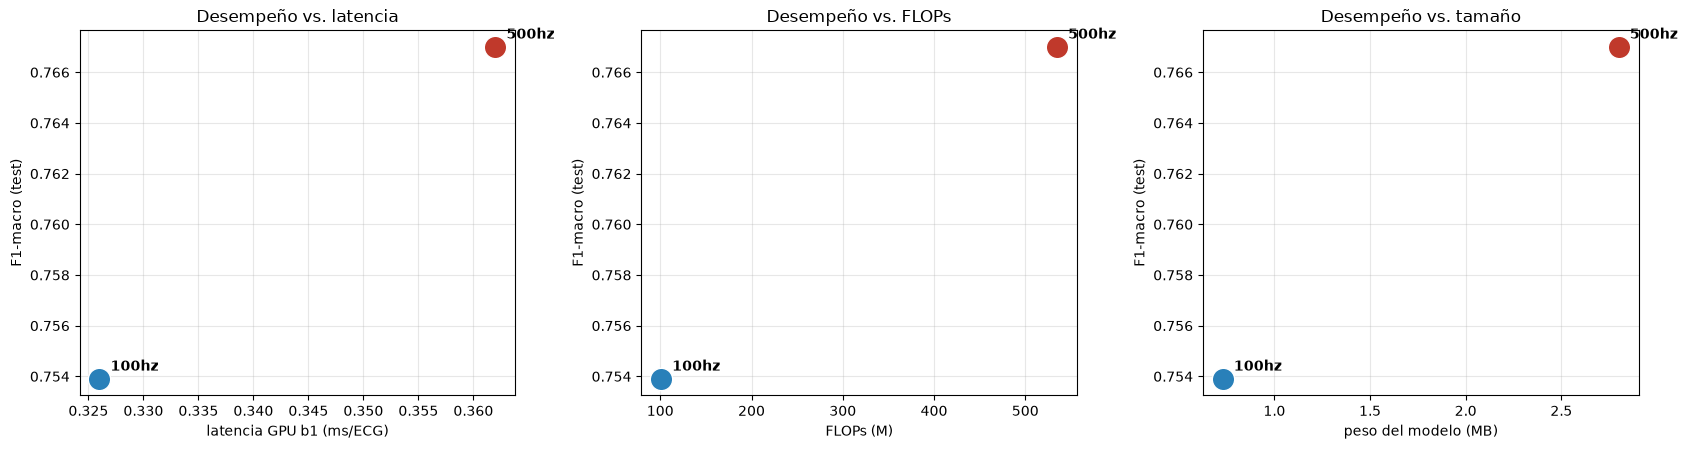

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
colors = {"100hz": "#2980b9", "500hz": "#c0392b"}

def scatter(a, xcol, xlabel, title):
    for k in CFG:
        a.scatter(size_df.loc[k, xcol], perf_df.loc[k, "F1_macro"],
                  s=260, color=colors[k], zorder=3, label=k, edgecolor="white")
        a.annotate(k, (size_df.loc[k, xcol], perf_df.loc[k, "F1_macro"]),
                   textcoords="offset points", xytext=(8, 6), fontsize=10, weight="bold")
    a.set_xlabel(xlabel); a.set_ylabel("F1-macro (test)"); a.set_title(title)
    a.grid(alpha=.3)

scatter(ax[0], "ms_x_ECG_GPU_b1", "latencia GPU b1 (ms/ECG)", "Desempeño vs. latencia")
scatter(ax[1], "FLOPs_M",         "FLOPs (M)",                "Desempeño vs. FLOPs")
scatter(ax[2], "peso_pt_MB",      "peso del modelo (MB)",     "Desempeño vs. tamaño")
plt.show()

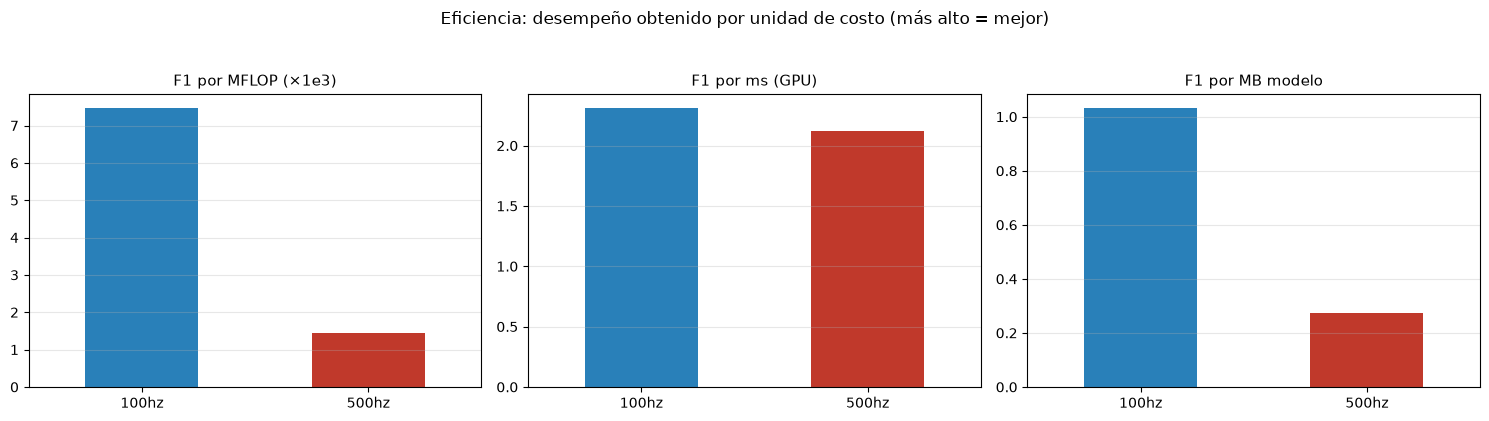

,F1 por MFLOP (×1e3),F1 por ms (GPU),F1 por MB modelo
100hz,7.4718,2.3126,1.0327
500hz,1.4342,2.1188,0.2739


In [13]:
# Barras: ¿cuánto cuesta cada punto de F1?  -> "eficiencia" = desempeño / costo
eff = pd.DataFrame({
    "F1 por MFLOP (×1e3)":  [perf_df.loc[k,"F1_macro"]/size_df.loc[k,"FLOPs_M"]*1e3 for k in CFG],
    "F1 por ms (GPU)":      [perf_df.loc[k,"F1_macro"]/size_df.loc[k,"ms_x_ECG_GPU_b1"] for k in CFG],
    "F1 por MB modelo":     [perf_df.loc[k,"F1_macro"]/size_df.loc[k,"peso_pt_MB"] for k in CFG],
}, index=list(CFG))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(axes, eff.columns):
    eff[col].plot.bar(ax=a, color=[colors[k] for k in CFG], rot=0)
    a.set_title(col, fontsize=11); a.grid(axis="y", alpha=.3)
fig.suptitle("Eficiencia: desempeño obtenido por unidad de costo (más alto = mejor)", y=1.04)
plt.tight_layout(); plt.show()
eff.round(4)

## 10 · Veredicto

Regla de decisión sencilla y transparente: el salto a 500 Hz **se justifica** solo si la mejora de
F1-macro supera un umbral mínimo que valga el sobrecosto de cómputo. Fijamos ese umbral en
**+0.01 absoluto de F1-macro** (ajústalo según tu criterio clínico).

In [14]:
f1_100, f1_500 = perf_df.loc["100hz","F1_macro"], perf_df.loc["500hz","F1_macro"]
delta   = f1_500 - f1_100
costo_x = float(summary.loc["FLOPs (M)", "x (500/100)"])
lat_x   = float(summary.loc["Latencia GPU b1 (ms)", "x (500/100)"])
UMBRAL  = 0.01

print(f"F1-macro  100 Hz : {f1_100:.4f}")
print(f"F1-macro  500 Hz : {f1_500:.4f}")
print(f"Δ F1-macro       : {delta:+.4f}   (umbral para justificar: +{UMBRAL})")
print(f"Sobrecosto 500 Hz: {costo_x:.1f}x FLOPs , {lat_x:.1f}x latencia , 5x tamaño de datos")
print("-" * 64)
if delta >= UMBRAL:
    print(f"VEREDICTO -> conviene 500 Hz: gana {delta:+.4f} de F1, suficiente para")
    print(f"             pagar {costo_x:.1f}x de cómputo. Sacrificar poder de cómputo SÍ vale.")
else:
    print(f"VEREDICTO -> conviene 100 Hz: la mejora ({delta:+.4f}) NO compensa {costo_x:.1f}x de")
    print(f"             cómputo y 5x de datos. Mejor el modelo ligero; NO vale sacrificar cómputo.")

F1-macro  100 Hz : 0.7539
F1-macro  500 Hz : 0.7670
Δ F1-macro       : +0.0131   (umbral para justificar: +0.01)
Sobrecosto 500 Hz: 5.3x FLOPs , 1.1x latencia , 5x tamaño de datos
----------------------------------------------------------------
VEREDICTO -> conviene 500 Hz: gana +0.0131 de F1, suficiente para
             pagar 5.3x de cómputo. Sacrificar poder de cómputo SÍ vale.


### Cómo leerlo

- Si **100 Hz** queda a la par (o casi) en F1/AUC, es la opción racional: misma capacidad
  diagnóstica con ~¼ de los parámetros, una fracción de los FLOPs, menor latencia y archivos de
  datos 5× más chicos — clave para despliegue en dispositivos modestos o procesamiento masivo.
- Si **500 Hz** abre una brecha clara (sobre todo en clases con morfología fina como `MI`/`STTC`,
  donde la resolución temporal alta ayuda), entonces el sobrecosto está justificado para un uso
  donde el costo de un falso negativo es alto.
- Revisa también la columna **Δ por clase** (sección 7) y la **eficiencia** (sección 9): a veces
  500 Hz solo ayuda en 1–2 clases, lo que sugiere un punto intermedio (p. ej. remuestrear a
  250 Hz) como trabajo futuro.